# 机器学习算法实践汇总

本 Notebook 汇总了从机器学习基础到高级主题的 sklearn 实践代码，每个二级标题对应一个核心主题。

## 0. sklearn 数据集与数据生成

在正式开始各类算法之前，先熟悉 **sklearn.datasets** 模块中常用的数据集加载与生成方法，这对后续实验和演示至关重要。

### 数据集分类

**1. 内置小型真实数据集（Toy Datasets）**
- `datasets.load_iris()`：鸢尾花数据集（分类，150 样本，4 特征）
- `datasets.load_digits()`：手写数字数据集（分类，1797 样本，64 特征）
- `datasets.load_wine()`：葡萄酒数据集（分类，178 样本，13 特征）
- `datasets.load_breast_cancer()`：乳腺癌数据集（分类，569 样本，30 特征）
- `datasets.load_diabetes()`：糖尿病数据集（回归，442 样本，10 特征）

**2. 人工生成数据集（Sample Generators）**
- `datasets.make_blobs()`：生成各向同性高斯斑点，常用于聚类与分类演示
- `datasets.make_moons()`：生成月牙形二分类数据，适合演示非线性决策边界
- `datasets.make_circles()`：生成同心圆二分类数据，适合演示非线性分类
- `datasets.make_classification()`：生成随机 N 分类数据，可控制特征数量、冗余、类别分离度等
- `datasets.make_regression()`：生成随机回归数据，可控制样本数、特征数、噪声等
- `datasets.make_swiss_roll()`：生成瑞士卷流形数据，常用于流形学习与降维

**3. 真实世界数据集（Real World Datasets）**
- `datasets.fetch_openml(name, version, as_frame)`：从 OpenML 平台获取数据集
- `datasets.fetch_20newsgroups()`：20 个新闻组文本分类数据
- `datasets.fetch_california_housing()`：加利福尼亚房价回归数据
- `datasets.fetch_lfw_people()`：人脸图片数据

### 核心 API 说明

**`sklearn.datasets.make_blobs`**
- 功能：生成各向同性高斯斑点（isotropic Gaussian blobs）
- 关键参数：
  - `n_samples`：样本总数
  - `n_features`：特征维度（默认 2）
  - `centers`：类别数或类别中心坐标
  - `cluster_std`：每个簇的标准差，控制数据分散程度
  - `random_state`：随机种子
- 返回值：`X, y`（特征矩阵与标签向量）

**`sklearn.datasets.make_moons`**
- 功能：生成两个月牙形交织的数据
- 关键参数：
  - `n_samples`：样本数
  - `noise`：高斯噪声标准差
  - `random_state`：随机种子

**`sklearn.datasets.make_circles`**
- 功能：生成二维同心圆数据
- 关键参数：
  - `n_samples`：样本数
  - `noise`：高斯噪声标准差
  - `factor`：内圆与外圆的半径比例（0~1）

### $Note$
`pyplot`是一个适应性怪强的库：如果给一个复数，他会主动只画实部；如果上述的`datasets`中有`n_features`的参数设来大于2，那么也会只取前两个维度来plot。

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. make_blobs
X, y = datasets.make_blobs(n_samples=300, centers=4, n_features=2, random_state=0, cluster_std=0.8)
axes[0, 0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[0, 0].set_title('make_blobs (centers=4)')

# 2. make_moons
noise = 0.5
X, y = datasets.make_moons(n_samples=300, noise=noise, random_state=0)
axes[0, 1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
axes[0, 1].set_title(f'make_moons (noise={noise})')

# 3. make_circles
X, y = datasets.make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)
axes[0, 2].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
axes[0, 2].set_title('make_circles (factor=0.5)')

# 4. make_classification
classes = 4
X, y = datasets.make_classification(n_samples=300, n_features=3, n_redundant=0, n_informative=2,
                                    n_clusters_per_class=1, n_classes=classes, random_state=0)
print(X.shape)
axes[1, 0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[1, 0].set_title(f'make_classification ( n_classes = {classes})')

# 5. make_regression
X, y = datasets.make_regression(n_samples=300, n_features=1, noise=20, random_state=0)
axes[1, 1].scatter(X, y, c='steelblue', edgecolor='k')
axes[1, 1].set_title('make_regression (1 feature)')

# 6. load_iris (前两个特征)
iris = datasets.load_iris()
X, y = iris.data[:, :2], iris.target
axes[1, 2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
axes[1, 2].set_title('load_iris (first 2 features)')

plt.tight_layout()
plt.show()

# 展示各数据集的 shape
print('=== 数据集示例 shape ===')
X_b, y_b = datasets.make_blobs(n_samples=200, centers=3, random_state=0)
print(f'make_blobs:       X{X_b.shape}, y{y_b.shape}')
X_m, y_m = datasets.make_moons(n_samples=200, random_state=0)
print(f'make_moons:       X{X_m.shape}, y{y_m.shape}')
X_c, y_c = datasets.make_circles(n_samples=200, random_state=0)
print(f'make_circles:     X{X_c.shape}, y{y_c.shape}')
X_cl, y_cl = datasets.make_classification(n_samples=200, n_features=5, random_state=0)
print(f'make_classification: X{X_cl.shape}, y{y_cl.shape}')
X_r, y_r = datasets.make_regression(n_samples=200, n_features=3, random_state=0)
print(f'make_regression:  X{X_r.shape}, y{y_r.shape}')
print(f'load_iris:        X{iris.data.shape}, y{iris.target.shape}')
print(f'load_digits:      X{datasets.load_digits().data.shape}, y{datasets.load_digits().target.shape}')

## 1. 机器学习基础与 KNN

### 核心 API 说明

**`sklearn.model_selection.train_test_split`**
- 功能：将数据集随机划分为训练集和测试集
- 关键参数：
  - `test_size`：测试集比例（如 `0.3` 表示 30%）
  - `random_state`：随机种子，保证结果可复现
- 返回值：`X_train, X_test, y_train, y_test`

**`sklearn.neighbors.KNeighborsClassifier`**
- 功能：K 近邻分类器
- 关键参数：
  - `n_neighbors`：邻居数 k，默认 5
- 主要方法：`.fit(X, y)`、`.predict(X)`、`.score(X, y)`

**`sklearn.model_selection.cross_val_score`**
- 功能：k-折交叉验证评分
- 关键参数：
  - `cv`：折数（常用 5 或 10）
  - `scoring`：评分指标，如 `'accuracy'`
- 返回值：每折分数的 numpy 数组

**`sklearn.model_selection.validation_curve`**
- 功能：验证曲线，用于评估不同超参数下的训练/测试表现
- 关键参数：
  - `param_name`：要扫描的参数名
  - `param_range`：参数取值范围
- 返回值：`train_scores, test_scores`（形状 `(n_values, cv)`）


In [ ]:
from sklearn import datasets, metrics, model_selection, neighbors
import matplotlib.pyplot as plt
import numpy as np

# 加载 iris 数据集
data = datasets.load_iris()
X, y = data.data, data.target

# 划分训练集与测试集 (7:3)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.3, random_state=42)
print('训练集样本数:', len(X_train), '测试集样本数:', len(X_test))

# KNN 训练与评估
model = neighbors.KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print('训练集准确率:', metrics.accuracy_score(y_train, model.predict(X_train)))
print('测试集准确率:', metrics.accuracy_score(y_test,  model.predict(X_test)))

# 5-折交叉验证
scores = model_selection.cross_val_score(model, X, y, cv=5)
print('交叉验证分数:', scores)
print('交叉验证均值:', scores.mean())

# 验证曲线：扫描 n_neighbors = 1~30
model = neighbors.KNeighborsClassifier()
train_scores, test_scores = model_selection.validation_curve(
    model, X, y, param_name='n_neighbors', param_range=range(1, 31), cv=5)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, 31), [np.mean(s) for s in test_scores],
        lw=2, marker='o', c='k', label='test_scores')
ax.plot(range(1, 31), [np.mean(s) for s in train_scores],
        lw=2, marker='o', c='r', label='train_scores')
ax.set_xlabel('n_neighbors'); ax.set_ylabel('accuracy')
ax.legend(); plt.show()

### 模型持久化

**`sklearn.externals.joblib`**（在较新版本中推荐使用 `joblib` 直接导入）
- `joblib.dump(model, filename)`：将训练好的模型保存到文件
- `joblib.load(filename)`：从文件加载模型


In [ ]:
import sklearn.externals.joblib as jb
from sklearn import neighbors, datasets, model_selection

# 以 digits 数据集为例训练并保存最优模型
digits = datasets.load_digits()
X, y = digits.data, digits.target
model = neighbors.KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)

jb.dump(model, 'knn_nb3')
loaded_model = jb.load('knn_nb3')
print('加载后交叉验证均值:',
      model_selection.cross_val_score(loaded_model, X, y, cv=5).mean())

## 2. 线性模型

### 核心 API 说明

**`sklearn.linear_model.LogisticRegression`**
- 功能：逻辑回归分类器（虽然名字里有 Regression，但本质是分类器）
- 关键参数：
  - `C`：正则化强度的倒数，默认 1.0
  - `solver`：优化算法，如 `'lbfgs'`、`'liblinear'`
- 主要方法：`.fit(X, y)`、`.predict(X)`、`.score(X, y)`


In [ ]:
from sklearn import linear_model, model_selection, datasets, neighbors

# 加载手写数字数据集
data = datasets.load_digits()
X, y = data.data, data.target

# 对比 KNN 与 LogisticRegression
for model, name in [
    [neighbors.KNeighborsClassifier(), 'KNN'],
    [linear_model.LogisticRegression(max_iter=1000), 'LogisticRegression']
]:
    scores = model_selection.cross_val_score(model, X, y, cv=5)
    print(f'{name:20s} cross_val_score: {scores}  mean={scores.mean():.4f}')

## 3. 支持向量机 (SVM)

### 核心 API 说明

**`sklearn.svm.SVC`**
- 功能：C-支持向量分类器
- 关键参数：
  - `kernel`：核函数类型，`'linear'`、`'rbf'`、`'poly'` 等
  - `C`：惩罚系数，控制对误分类的容忍度
- 主要属性：
  - `support_vectors_`：支持向量坐标
  - `decision_function(X)`：样本到决策边界的距离
- 主要方法：`.fit(X, y)`、`.predict(X)`


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# --- 线性核 SVM ---
X, y = datasets.make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)
clf = SVC(kernel='linear')
clf.fit(X, y)

# 可视化决策函数与 margin
def plot_svc_decision_function(clf, ax=None):
    if ax is None:
        ax = plt.gca()
    x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 30)
    y = np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], 30)
    X_grid, Y_grid = np.meshgrid(x, y)
    P = np.zeros_like(X_grid)
    for i, xi in enumerate(x):
        for j, yj in enumerate(y):
            P[j, i] = clf.decision_function([[xi, yj]])
    ax.contour(X_grid, Y_grid, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=150, marker='*', c='k', label='support_vectors')
plt.legend(); plt.show()

# --- 非线性核 RBF ---
X, y = datasets.make_circles(n_samples=100, factor=.1, noise=.1)
clf = SVC(kernel='rbf', C=1).fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring')
plot_svc_decision_function(clf)
plt.title('SVM with RBF kernel'); plt.show()

# --- moons 数据 ---
X, y = datasets.make_moons(noise=0.1)
clf = SVC(kernel='rbf', C=200).fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='spring')
plot_svc_decision_function(clf)
plt.title('SVM on moons'); plt.show()

## 4. 决策树

### 核心 API 说明

**`sklearn.tree.DecisionTreeClassifier`**
- 功能：决策树分类器
- 关键参数：
  - `criterion`：分裂准则，`'gini'`（基尼不纯度）或 `'entropy'`（信息熵）
  - `max_depth`：树的最大深度，防止过拟合
- 主要方法：`.fit(X, y)`、`.predict(X)`、`.score(X, y)`


In [ ]:
from sklearn import tree, datasets, model_selection
import numpy as np
import matplotlib.pyplot as plt

# 生成 2D  blobs 数据
X, y = datasets.make_blobs(n_samples=300, centers=5, n_features=2, random_state=1)

# 训练决策树
clf = tree.DecisionTreeClassifier(criterion='gini')
clf.fit(X, y)
print('训练集准确率:', clf.score(X, y))
print('5-折交叉验证:', model_selection.cross_val_score(clf, X, y, cv=5))

# 决策面可视化辅助函数
def ml_plot(X, y, clf, ngrid=50, title=''):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='spring')
    clf.fit(X, y)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, ngrid),
                         np.linspace(y_min, y_max, ngrid))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='spring')
    ax.set_title(title)
    plt.show()

ml_plot(X, y, clf, title='Decision Tree Decision Surface')

## 5. 集成学习

### 核心 API 说明

**`sklearn.ensemble.RandomForestClassifier`**
- 功能：随机森林分类器（多棵决策树的 Bagging 集成）
- 关键参数：
  - `n_estimators`：树的数量
  - `max_depth`：每棵树的最大深度
- 方法：`.fit(X, y)`、`.predict(X)`

**`sklearn.ensemble.AdaBoostClassifier`**
- 功能：自适应提升分类器
- 关键参数：
  - `n_estimators`：弱学习器数量
  - `learning_rate`：学习率，控制每个弱学习器的贡献权重
- 方法：`.fit(X, y)`、`.predict(X)`

**`sklearn.ensemble.GradientBoostingClassifier`**
- 功能：梯度提升决策树（GBDT）
- 关键参数：
  - `n_estimators`：树的数量
  - `learning_rate`：学习率
- 方法：`.fit(X, y)`、`.predict(X)`


In [ ]:
from sklearn import ensemble, datasets, model_selection
import numpy as np
import matplotlib.pyplot as plt

X, y = datasets.make_blobs(n_samples=300, centers=5, n_features=2, random_state=1)

def ml_plot(X, y, clf, ngrid=50, title=''):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='spring')
    clf.fit(X, y)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, ngrid),
                         np.linspace(y_min, y_max, ngrid))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='spring')
    ax.set_title(title); plt.show()

# 随机森林
clf = ensemble.RandomForestClassifier(n_estimators=100, random_state=1)
print('RandomForest score:', clf.fit(X, y).score(X, y))
ml_plot(X, y, clf, title='Random Forest')

# AdaBoost
clf = ensemble.AdaBoostClassifier(algorithm='SAMME.R', learning_rate=2, random_state=1)
print('AdaBoost score:', clf.fit(X, y).score(X, y))
ml_plot(X, y, clf, title='AdaBoost')

# GBDT
clf = ensemble.GradientBoostingClassifier(random_state=1)
print('GBDT score:', clf.fit(X, y).score(X, y))
print('GBDT cross_val:', model_selection.cross_val_score(clf, X, y, cv=5))
ml_plot(X, y, clf, title='Gradient Boosting')

## 6. 神经网络 (MLP)

### 核心 API 说明

**`sklearn.neural_network.MLPClassifier`**
- 功能：多层感知机分类器
- 关键参数：
  - `hidden_layer_sizes`：隐藏层神经元数量元组，如 `(100,)` 或 `(50, 20)`
  - `activation`：激活函数，`'relu'`、`'tanh'`、`'logistic'`、`'identity'` 等
  - `max_iter`：最大迭代次数
- 主要方法：`.fit(X, y)`、`.predict(X)`、`.score(X, y)`、`.get_params()`


In [ ]:
from sklearn import neural_network, model_selection, metrics, datasets
import matplotlib.pyplot as plt
import numpy as np

# --- moons 数据 ---
X, y = datasets.make_moons(500, noise=0.15, random_state=1)
model = neural_network.MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=1000, random_state=1)
model.fit(X, y)
y_predict = model.predict(X)
print('moons accuracy:', metrics.accuracy_score(y, y_predict))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].scatter(X[:, 0], X[:, 1], c=y, cmap='rainbow')
axs[0].set_title('original data')
axs[1].scatter(X[:, 0], X[:, 1], c=y_predict, cmap='rainbow')
axs[1].set_title('predicted data')
plt.show()

print('cross_val_score:', model_selection.cross_val_score(model, X, y, cv=5))

# --- 对比 activation='identity'（无法拟合非线性） ---
model_id = neural_network.MLPClassifier(hidden_layer_sizes=(50, 20),
                                         activation='identity', max_iter=1000, random_state=1)
model_id.fit(X, y)
y_id = model_id.predict(X)
print('identity activation accuracy:', metrics.accuracy_score(y, y_id))

# --- circles 数据 ---
X, y = datasets.make_circles(500, noise=0.1, factor=0.5, random_state=2)
model = neural_network.MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=1000, random_state=1)
model.fit(X, y)
y_predict = model.predict(X)
print('circles accuracy:', metrics.accuracy_score(y, y_predict))

# --- digits 数据：不同 hidden_layer_sizes 对比 ---
digits = datasets.load_digits()
X, y = digits.data, digits.target

print('\n=== digits 不同架构对比 ===')
for hidden_layer_sizes in [(20,), (50,), (100,), (200,),
                            (100, 10), (300, 10), (100, 20, 10)]:
    model = neural_network.MLPClassifier(hidden_layer_sizes, max_iter=1000, random_state=1)
    scores = model_selection.cross_val_score(model, X, y, cv=5)
    print(f'{str(hidden_layer_sizes):20s} mean={scores.mean():.4f}')

## 7. 卷积神经网络 (CNN) —— Keras 实现

> **注意**：本节使用 Keras（TensorFlow 后端）而非 sklearn，作为深度学习图像分类的实践参考。

### 核心 API 说明

**`keras.models.Sequential`**
- 功能：顺序堆叠各层的神经网络模型
- 方法：`.add(layer)`、`.compile(...)`、`.fit(...)`、`.evaluate(...)`

**常用层**
- `Conv2D(filters, kernel_size, activation, padding)`：二维卷积层
- `MaxPooling2D(pool_size)`：二维最大池化层
- `Flatten()`：将多维特征图展平为一维
- `Dense(units, activation)`：全连接层
- `Dropout(rate)`：随机失活，防止过拟合
- `BatchNormalization()`：批归一化

**`model.compile`**
- 关键参数：
  - `optimizer`：优化器，如 `Adadelta()`、`Adam()`
  - `loss`：损失函数，如 `'categorical_crossentropy'`
  - `metrics`：评估指标列表，如 `['accuracy']`


In [2]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from keras import backend as K

# 参数设置
batch_size = 128
num_classes = 10
epochs = 12
img_rows, img_cols = 28, 28

# 加载 MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 根据 backend 调整通道位置
if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test  = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test  = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# 归一化
x_train = x_train.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

# one-hot 编码
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

# 搭建 CNN
model = Sequential([
    BatchNormalization(input_shape=input_shape),
    Conv2D(4, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(8, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adadelta(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs,
          verbose=1, validation_data=(x_test, y_test))

# 评估
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/12
469/469 [==============================] - 22s 44ms/step - loss: 2.3158 - accuracy: 0.1032 - val_loss: 2.2940 - val_accuracy: 0.0808
Epoch 2/12
469/469 [==============================] - 11s 23ms/step - loss: 2.3110 - accuracy: 0.1060 - val_loss: 2.2880 - val_accuracy: 0.0940
Epoch 3/12
469/469 [==============================] - 7s 14ms/step - loss: 2.3033 - accuracy: 0.1105 - val_loss: 2.2823 - val_accuracy: 0.1087
Epoch 4/12
469/469 [==============================] - 7s 16ms/step - loss: 2.2967 - accuracy: 0.1184 - val_loss: 2.2768 - val_accuracy: 0.1278
Epoch 5/12
469/469 [==============================] - 9s 19ms/step - loss: 2.2919 - accuracy: 0.1203 - val_loss: 2.2714 - val_accuracy: 0.1451
Epoch 6/12
469/469 [==============================] - 10s 22ms/step - loss: 2.2872 - accuracy: 0.1242 - val_loss: 2.2661 - val_accuracy: 0.1607
Epoch 7/12
469/469 [==============================] - 7s 15ms/step - loss: 2.2807 - accuracy: 0.1318 - val_loss: 2.2607 - val_accuracy: 0.1

## 8. 聚类

### 核心 API 说明

$\textcolor{red}{注：如果出现}$ `model = cluster.KMeans(n_clusters=4, random_state=0)`$\textcolor{red}{的报错，可以考虑换用低级一点的python版本}$

**`sklearn.cluster.KMeans`**
- 功能：K-Means 聚类
- 关键参数：
  - `n_clusters`：簇的数量 k
- 主要方法：`.fit(X)`、`.predict(X)`、`.fit_predict(X)`
- 主要属性：`cluster_centers_`（簇中心坐标）

**`sklearn.cluster.MiniBatchKMeans`**
- 功能：小批量 K-Means，加速大数据集聚类
- 关键参数：
  - `n_clusters`：簇的数量
  - `batch_size`：每批样本数

**`sklearn.mixture.GaussianMixture`**
- 功能：高斯混合模型（软聚类）
- 关键参数：
  - `n_components`：高斯分量数
- 主要方法：`.fit(X)`、`.predict(X)`

**`sklearn.cluster.SpectralClustering`**
- 功能：谱聚类
- 关键参数：`n_clusters`

**`sklearn.cluster.DBSCAN`**
- 功能：基于密度的空间聚类
- 关键参数：
  - `eps`：邻域半径
  - `min_samples`：核心点邻域最小样本数

**聚类评估指标**
- `metrics.adjusted_rand_score(y_true, y_pred)`：调整兰德指数（Adjusted Rand Index, ARI）
  - **意义**：衡量聚类结果与真实标签的相似程度，并对随机标签进行校正。取值范围为 **[-1, 1]**，**越接近 1 表示聚类结果与真实标签越一致**；0 表示与随机标签相当；负值表示比随机更差。
- `metrics.adjusted_mutual_info_score(y_true, y_pred)`：调整互信息（Adjusted Mutual Information, AMI）
  - **意义**：基于信息论衡量两个分布的相互依赖程度，同样校正了随机因素。取值范围为 **[0, 1]**，**越接近 1 表示聚类结果与真实标签的吻合度越高**；0 表示两者独立（无关联）。
- `metrics.silhouette_score(X, labels)`：轮廓系数（Silhouette Coefficient）
  - **意义**：无需真实标签，衡量样本与自身簇的紧密度和与其他簇的分离度。取值范围为 **[-1, 1]**，**越接近 1 表示簇内越紧密、簇间越分离**；接近 0 表示样本位于两个簇的边界附近；负值表示样本可能被分到了错误的簇。


d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


KMeans time: 0.070s, MiniBatchKMeans time: 0.241s


d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


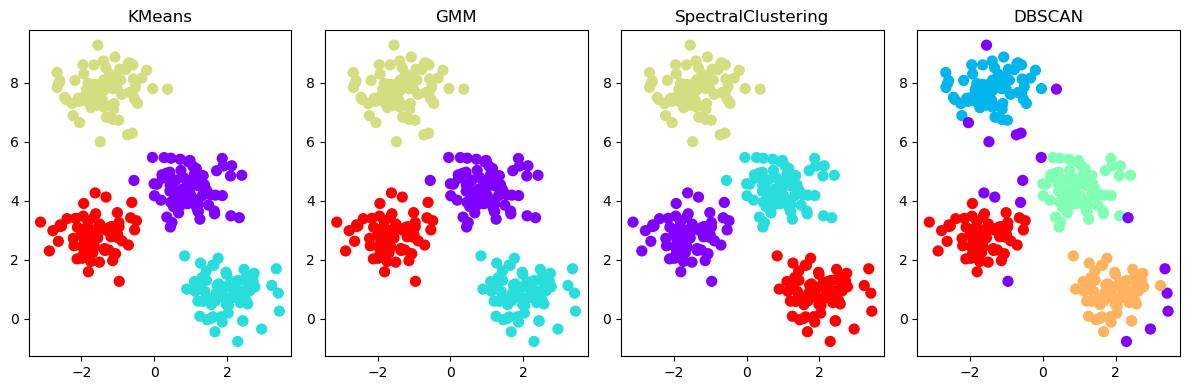

d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
d:\ANACONDA\envs\tf\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


KMeans               ARI=0.6154 AMI=0.7278 Silhouette=0.1856
MiniBatchKMeans      ARI=0.5970 AMI=0.7150 Silhouette=0.1836
GMM                  ARI=0.6113 AMI=0.7256 Silhouette=0.1658


In [1]:
from sklearn import cluster, datasets, metrics, mixture
import numpy as np
import matplotlib.pyplot as plt

# 生成示例数据
X, y = datasets.make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=0.60)

# --- KMeans ---
model = cluster.KMeans(n_clusters=4, random_state=0)
y_means = model.fit_predict(X)
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_means, s=50, cmap='rainbow')
plt.title('KMeans')

# --- MiniBatchKMeans（大数据对比） ---
X_big, _ = datasets.make_blobs(100000, centers=8, random_state=0, cluster_std=1.5)
import time
t1 = time.time()
cluster.KMeans(8, random_state=0).fit_predict(X_big)
t2 = time.time()
t3 = time.time()
cluster.MiniBatchKMeans(8, batch_size=1000, random_state=0).fit_predict(X_big)
t4 = time.time()
print(f'KMeans time: {t2-t1:.3f}s, MiniBatchKMeans time: {t4-t3:.3f}s')

# --- GaussianMixture ---
model = mixture.GaussianMixture(n_components=4, random_state=0)
model.fit(X)
y_gmm = model.predict(X)
plt.subplot(1, 4, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, s=50, cmap='rainbow')
plt.title('GMM')

# --- SpectralClustering ---
model = cluster.SpectralClustering(n_clusters=4, random_state=0)
y_sc = model.fit_predict(X)
plt.subplot(1, 4, 3)
plt.scatter(X[:, 0], X[:, 1], c=y_sc, s=50, cmap='rainbow')
plt.title('SpectralClustering')

# --- DBSCAN ---
model = cluster.DBSCAN(eps=0.5)
y_db = model.fit_predict(X)
plt.subplot(1, 4, 4)
plt.scatter(X[:, 0], X[:, 1], c=y_db, s=50, cmap='rainbow')
plt.title('DBSCAN')
plt.tight_layout(); plt.show()

# --- 评估指标（以 digits 为例） ---
digits = datasets.load_digits()
X_d, y_d = digits.data, digits.target
for model, name in [
    (cluster.KMeans(n_clusters=10, random_state=0), 'KMeans'),
    (cluster.MiniBatchKMeans(n_clusters=10, random_state=0), 'MiniBatchKMeans'),
    (mixture.GaussianMixture(n_components=10, random_state=0), 'GMM'),
]:
    if name == 'GMM':
        y_pred = model.fit(X_d).predict(X_d)
    else:
        y_pred = model.fit_predict(X_d)
    ari = metrics.adjusted_rand_score(y_d, y_pred)
    ami = metrics.adjusted_mutual_info_score(y_d, y_pred)
    sil = metrics.silhouette_score(X_d, y_pred)
    print(f'{name:20s} ARI={ari:.4f} AMI={ami:.4f} Silhouette={sil:.4f}')

## 9. 降维

### 核心 API 说明

**`sklearn.decomposition.PCA`**
- 功能：主成分分析（线性降维）
- 关键参数：
  - `n_components`：保留的主成分数；若传入 `0~1` 小数，表示保留的方差比例
- 主要属性：
  - `components_`：主成分方向向量
  - `explained_variance_ratio_`：各主成分的方差解释率
- 主要方法：
  - `.fit(X)`：用数据 `X` 学习主成分方向（计算均值、协方差矩阵并分解），不改变 `X` 的维度
  - `.transform(X)`：将已学习的 PCA 模型应用于新数据 `X`，将其投影到主成分空间，返回降维后的数据
  - `.fit_transform(X)`：等同于先执行 `.fit(X)` 再执行 `.transform(X)`，是训练并降维的快捷写法
  - `.inverse_transform(X_reduced)`：将降维后的数据反投影回原始特征空间，可用于观察降维造成的信息损失（重构误差）

**`sklearn.manifold.LocallyLinearEmbedding`**
- 功能：局部线性嵌入（非线性流形学习）
- 关键参数：
  - `n_neighbors`：近邻数 k
  - `n_components`：降维后的维度
- 方法：`.fit_transform(X)`

**其他流形学习方法**
- `sklearn.manifold.Isomap`
- `sklearn.manifold.SpectralEmbedding`
- `sklearn.manifold.TSNE`


(200, 2)
components:
 [[-0.94446029 -0.32862557]
 [-0.32862557  0.94446029]]
explained_variance_ratio_: [0.97634101 0.02365899]
降维后维度: 1
原始维度: (1797, 64) 降维后: (1797, 2)


C:\Users\J3540\AppData\Local\Temp\ipykernel_23140\793773527.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  alpha=0.5, cmap=plt.cm.get_cmap('nipy_spectral', 10))


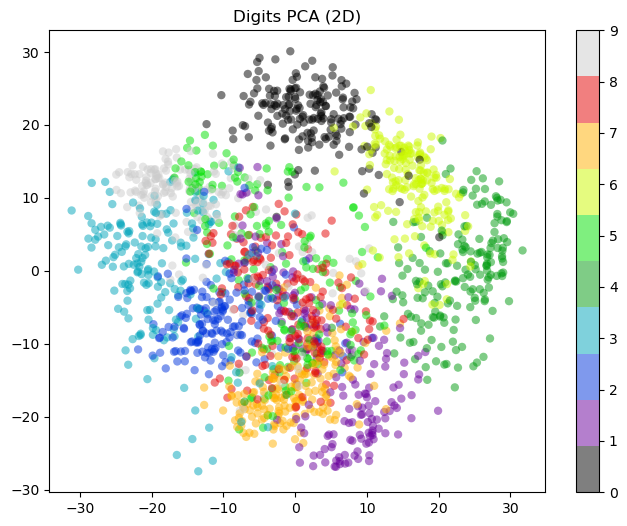


=== 不同 PCA 维度下的分类器表现 ===


d:\ANACONDA\Lib\site-packages\sklearn\model_selection\_validation.py:794: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\ANACONDA\Lib\site-packages\sklearn\metrics\_scorer.py", line 117, in __call__
    score = scorer(estimator, *args, **kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\site-packages\sklearn\metrics\_scorer.py", line 444, in _passthrough_scorer
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\site-packages\sklearn\base.py", line 668, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                             ^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\site-packages\sklearn\neighbors\_classification.py", line 234, in predict
    neigh_ind = self.kneighbors(X, return_distance=False)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KNN             orig=nan  dim2=0.6032  dim8=0.9227  dim16=nan


d:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\ANACONDA\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result

Logistic        orig=0.9121  dim2=0.5871  dim8=0.8698  dim16=0.8943
SVM-rbf         orig=0.9633  dim2=0.6361  dim8=0.9238  dim16=0.9655
DecisionTree    orig=0.7864  dim2=0.5682  dim8=0.8197  dim16=0.8231
RandomForest    orig=0.9382  dim2=0.6038  dim8=0.9054  dim16=0.9293
NaiveBayes      orig=0.8069  dim2=0.6271  dim8=0.8620  dim16=0.9010


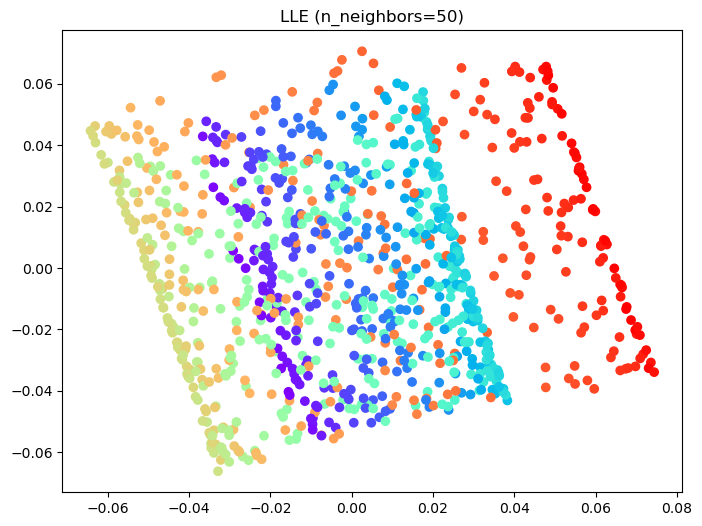

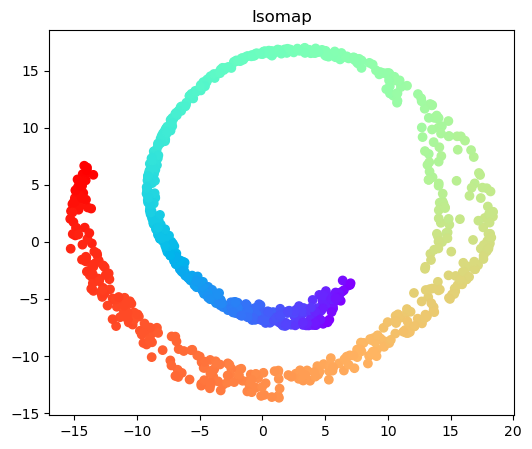

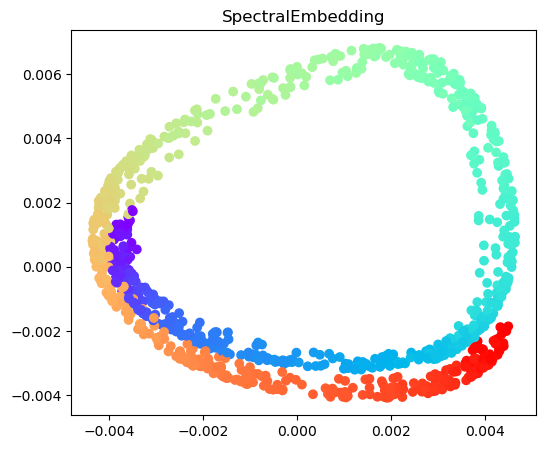

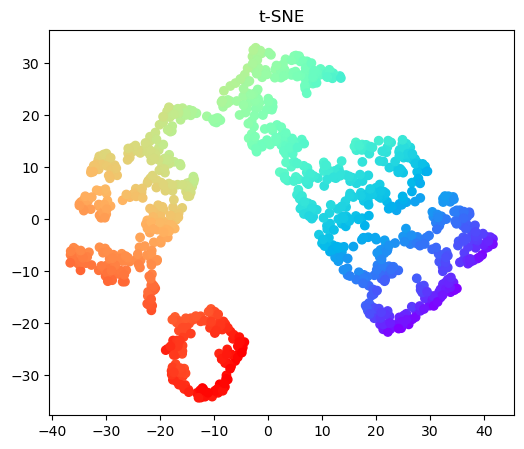

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets, model_selection
from sklearn import neighbors, linear_model, svm, ensemble, naive_bayes, tree

# --- 2D 数据 PCA 演示 ---
np.random.seed(1)

# 第一个np.random.random是生成的变化矩阵
# 第二个则是在生成数据点
# 原始数据是标准的、轴对齐的正态分布，经过随机线性变换后，数据变成斜向分布的（有相关性、有方向性），这样PCA的效果才明显。
X = np.dot(np.random.random(size=(2, 2)), np.random.normal(size=(2, 200))).T

pca = PCA(n_components=2)
pca.fit(X)
print('components:\n', pca.components_)
print('explained_variance_ratio_:', pca.explained_variance_ratio_)

# 保留 95% 方差
model = PCA(0.95)
model.fit(X)
print('降维后维度:', model.n_components_)
X_new = model.inverse_transform(model.transform(X))

# --- Digits 数据集 PCA ---
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target

pca = PCA(n_components=2)
Xproj = pca.fit_transform(X)
print('原始维度:', X.shape, '降维后:', Xproj.shape)

plt.figure(figsize=(8, 6))
plt.scatter(Xproj[:, 0], Xproj[:, 1], c=y, edgecolor='none',
            alpha=0.5, cmap=plt.cm.get_cmap('nipy_spectral', 10))
plt.colorbar(); plt.title('Digits PCA (2D)'); plt.show()

# --- 不同维度下分类器表现对比 ---
pca2 = PCA(n_components=2).fit(X)
pca8 = PCA(n_components=8).fit(X)
pca16 = PCA(n_components=16).fit(X)
X1 = pca2.transform(X)
X2 = pca8.transform(X)
X3 = pca16.transform(X)

models = [
    (neighbors.KNeighborsClassifier(), 'KNN'),
    (linear_model.LogisticRegression(max_iter=1000), 'Logistic'),
    (svm.SVC(kernel='rbf'), 'SVM-rbf'),
    (tree.DecisionTreeClassifier(), 'DecisionTree'),
    (ensemble.RandomForestClassifier(random_state=1), 'RandomForest'),
    (naive_bayes.GaussianNB(), 'NaiveBayes')
]

print('\n=== 不同 PCA 维度下的分类器表现 ===')
for model, name in models:
    r0 = model_selection.cross_val_score(model, X,  y, cv=5).mean()
    r1 = model_selection.cross_val_score(model, X1, y, cv=5).mean()
    r2 = model_selection.cross_val_score(model, X2, y, cv=5).mean()
    r3 = model_selection.cross_val_score(model, X3, y, cv=5).mean()
    print(f'{name:15s} orig={r0:.4f}  dim2={r1:.4f}  dim8={r2:.4f}  dim16={r3:.4f}')

# --- 非线性降维：LLE on Swiss Roll ---
from sklearn import manifold

X_swiss, t = datasets.make_swiss_roll(n_samples=1000, random_state=30)

model = manifold.LocallyLinearEmbedding(n_neighbors=50, n_components=2, random_state=1)
X_lle = model.fit_transform(X_swiss)
plt.figure(figsize=(8, 6))
plt.scatter(X_lle[:, 0], X_lle[:, 1], c=t, cmap=plt.cm.rainbow)
plt.title('LLE (n_neighbors=50)'); plt.show()

# 对比其他流形学习方法
for Method, kwargs, title in [
    (manifold.Isomap, {'n_neighbors': 50}, 'Isomap'),
    (manifold.SpectralEmbedding, {'n_components': 2}, 'SpectralEmbedding'),
    (manifold.TSNE, {'n_components': 2, 'random_state': 1}, 't-SNE')
]:
    model = Method(**kwargs)
    X_emb = model.fit_transform(X_swiss)
    plt.figure(figsize=(6, 5))
    plt.scatter(X_emb[:, 0], X_emb[:, 1], c=t, cmap=plt.cm.rainbow)
    plt.title(title); plt.show()

## Regression

补充一下关于常用Regularization的知识：

| 范数             | 公式                                          | 核心意义                                                              |
| :------------- | :------------------------------------------ | :---------------------------------------------------------------- |
| **L0**         | $\|x\|_0 = \sum_{i} \mathbf{1}(x_i \neq 0)$ | 向量中非零元素的个数。直接衡量稀疏性，但非凸、不连续，优化属于 NP-hard 问题。                       |
| **L1**         | $\|x\|_1 = \sum_{i} \|x_i\|$                | 绝对值之和。作为 L0 的凸松弛，常用于 **Lasso 回归**，能在优化过程中将部分系数精确压缩至 0，实现**稀疏解**与特征选择。 |
| **L2**         | $\|x\|_2 = \sqrt{\sum_{i} x_i^2}$           | 欧几里得范数。用于**岭回归**，惩罚大权重但不强制置零，使参数趋于平滑、数值稳定，有效缓解多重共线性。                  |
| **$L_\infty$** | $\|x\|_\infty = \max_i \|x_i\|$             | 最大绝对值分量。限制单个元素的最大幅度，常用于对抗样本防御或 box 约束优化，确保所有分量被统一上界控制。            |

关于线性回归的Hyperparameter将在对应cell上方讲解


In [ ]:
from sklearn import datasets
from sklearn import neighbors, naive_bayes, linear_model, svm, neural_network, tree, ensemble

from sklearn import  model_selection, metrics, preprocessing
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('seaborn')

#### 1. Visulization Function

In [ ]:
def ml_plot(X, y, model, ngrid=50, title='', deg=1, make_plot=True):
    
    if make_plot:
        fig, ax = plt.subplots(figsize=(8,5))
        ax.scatter(X, y,)
    
    # << Enhance the order of X >>
    X_extended = np.column_stack([np.array(X).reshape(len(X),-1)**n for n in range(1, deg+1)])

    model.fit(X_extended, y)
    
    cvscore = np.mean(model_selection.cross_val_score(model, X_extended, y, scoring='neg_mean_squared_error',
            cv=5))
    if make_plot:
        X2 = np.linspace(min(np.array(X)), max(np.array(X)), 100); 
        X2_extended = np.column_stack([np.array(X2).reshape(len(X2),-1)**n for n in range(1, deg+1)])
        y2 = model.predict(X2_extended)
        ax.plot(X2, y2, lw=2, c='k' ) #colors='k',

        if title != '':
            ax.set_title(title+'; cross_score = %.2f'%cvscore, fontsize=14)
        plt.show()
    return model_selection.cross_val_score(model, X_extended, y, scoring='neg_mean_squared_error', cv=5)

#### 2. 对一个二阶多项式进行回归

- Lasso和Ridge的本质都是线性回归+正则，所以有两个超参数：`deg`控制多项式阶数，`alpha`控制正则化强度。
- 其它则是类似于大杂烩，我们能发现之前介绍的各种Classification Model都有Regressor版本。


In [ ]:
X = np.random.random(size=30); #X = [[xx] for xx in X]; X = np.array(X)
y = 4*X**4 + X + 1 + np.random.normal(scale=0.5, size=30)
data_name = 'y = 4*x^2 + x + 1     300 points    error = N(0,0.5) '

model_names, scores = [], []

for model, deg, text in [
    [linear_model.LinearRegression(), 1, 'linear'],
    [linear_model.LinearRegression(), 2, 'linear, deg=2'],
    [linear_model.LinearRegression(), 15, 'linear, deg=15'],
    [linear_model.Ridge(alpha=0.1), 15, 'Ridge, deg=15,\n alpha=0.1'],
    [linear_model.Ridge(alpha=100), 15, 'Ridge, deg=15,\n alpha=100'],
    
    [linear_model.Lasso(alpha=0.01), 15, 'lasso, deg=15,\n alpha=0.01'],
    
    [linear_model.Lasso(alpha=0.1), 15, 'lasso, deg=15,\n alpha=0.1'],
    
    [linear_model.Lasso(alpha=1), 15, 'lasso, deg=15,\n alpha=1'],
    
    [linear_model.Lasso(alpha=100), 15, 'lasso, deg=15,\n alpha=100'],
    
    [neighbors.KNeighborsRegressor(n_neighbors=5), 1, 'knn (n=5)'],
    
    [svm.SVR(kernel='linear'), 1, 'linear svm'],
    [svm.SVR(kernel='rbf'), 1, 'rbf svm'],
    
    [tree.DecisionTreeRegressor(), 1, 'decision tree'],
    
    [ensemble.RandomForestRegressor(), 1, 'Random forest'],
    [ensemble.AdaBoostRegressor(), 1, 'AdaBoost'],
    [ensemble.GradientBoostingRegressor(), 1, 'GradientBoost'],
    
    [neural_network.MLPRegressor((100,)), 1, '10 MLP'],
    [neural_network.MLPRegressor((200,10)), 1, '200/10 MLP'],
    [neural_network.MLPRegressor((200,10), max_iter=1000), 1, '200/10 MLP'],
    ]:
    
        cvscores = ml_plot(X, y, model, title=text, deg=deg, make_plot=True)
        model_names.append(text); scores.append(cvscores)
        
fig, ax = plt.subplots(figsize=(18,4.5))
for imodel in range(len(model_names)):
    model_name, score = model_names[imodel], scores[imodel]
    X = [imodel+1+(i-2)*0.05 for i in range(len(score))]
    ax.scatter(X, score)
ax.set_xticks(range(1,len(model_names)+1))
ax.set_xticklabels(model_names, rotation=30, fontsize=12)
ax.set_title(data_name, fontsize=14)

#### 3. 对Boston房价进行回归

会遇到一个很有趣的报错：

```python
ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.
```
load_boston 数据集因为伦理问题（包含种族歧视变量）已在 scikit-learn 1.2+ 版本中被移除。


In [ ]:
boston_data = datasets.load_boston()
print(boston_data.DESCR)
X, y = boston_data.data, boston_data.target
data_name = 'Boston house price '

model_names, scores = [], []

for model, deg, text in [
    [linear_model.LinearRegression(), 1, 'linear'],
    [linear_model.LinearRegression(), 2, 'linear, deg=2'],
    [linear_model.LinearRegression(), 3, 'linear, deg=3'],
    [linear_model.Ridge(alpha=0.1), 1, 'Ridge, deg=1,\n alpha=0.1'],
    [linear_model.Ridge(alpha=100), 1, 'Ridge, deg=1,\n alpha=100'],
    
    [linear_model.Lasso(alpha=0.01), 1, 'lasso, deg=1,\n alpha=0.01'],
    
    [neighbors.KNeighborsRegressor(n_neighbors=5), 1, 'knn (n=5)'],
    
    [svm.SVR(kernel='linear'), 1, 'linear svm'],
    [svm.SVR(kernel='rbf'), 1, 'rbf svm'],
    
    [tree.DecisionTreeRegressor(), 1, 'decision tree'],
    
    [ensemble.RandomForestRegressor(), 1, 'Random forest'],
    [ensemble.AdaBoostRegressor(), 1, 'AdaBoost'],
    [ensemble.GradientBoostingRegressor(), 1, 'GradientBoost'],
    
    [neural_network.MLPRegressor((200,10)), 1, '200/10 MLP'],
    ]:
    
        cvscores = ml_plot(X, y, model, title=text, deg=deg, make_plot=False)
        model_names.append(text); scores.append(cvscores)
        
fig, ax = plt.subplots(figsize=(18,4.5))
for imodel in range(len(model_names)):
    model_name, score = model_names[imodel], scores[imodel]
    X = [imodel+1+(i-2)*0.05 for i in range(len(score))]
    ax.scatter(X, score)
ax.set_xticks(range(1,len(model_names)+1))
ax.set_xticklabels(model_names, rotation=30, fontsize=12)
ax.set_title(data_name, fontsize=14)